In [9]:
# ==============================================================
# FARMER DECISION SUPPORT SYSTEM
# COMPLETE END-TO-END NOTEBOOK PIPELINE
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# ==============================================================
# LOAD DATASETS
# ==============================================================

ranking_df = pd.read_csv("../processed_data/best_crop_mandi_ranking.csv")
mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")

print("Datasets Loaded")

# ==============================================================
# CLEAN COLUMN NAMES
# ==============================================================

ranking_df.columns = ranking_df.columns.str.lower().str.replace(" ","_")
mandi_df.columns = mandi_df.columns.str.lower().str.replace(" ","_")

print("Ranking Columns:", ranking_df.columns)
print("Mandi Columns:", mandi_df.columns)

# ==============================================================
# AUTO DETECT DATE COLUMN
# ==============================================================

possible_dates = ["price_date","arrival_date","date","reported_date"]

date_col = None
for col in mandi_df.columns:
    if col in possible_dates:
        date_col = col
        break

if date_col is None:
    raise Exception("No date column found in mandi dataset")

print("Using Date Column:", date_col)

mandi_df[date_col] = pd.to_datetime(mandi_df[date_col])

# ==============================================================
# STATE INPUT
# ==============================================================

states = ranking_df["state"].dropna().unique()

print("\nAvailable States:\n")
print(states)

STATE = input("\nEnter State: ")

# ==============================================================
# TOP 5 CROP RECOMMENDATION
# ==============================================================

state_data = ranking_df[
    ranking_df["state"].str.lower() == STATE.lower()
]

if state_data.empty:
    raise Exception("No crop data found for this state")

top5 = state_data.sort_values("rank").head(5)

print("\nTop 5 Recommended Crops\n")
print(top5[["crop","predicted_yield","modal_price"]])

# ==============================================================
# MANDI DATA FOR STATE
# ==============================================================

mandi_state = mandi_df[
    mandi_df["state"].str.lower() == STATE.lower()
]

mandi_state = mandi_state.dropna(subset=["modal_price"])

if len(mandi_state) < 20:
    raise Exception("Not enough mandi data for this state")

# ==============================================================
# PREPARE TIME SERIES
# ==============================================================

weekly = mandi_state[[date_col,"modal_price"]].copy()

weekly = weekly.rename(columns={
    date_col:"Price_Date",
    "modal_price":"Modal_Price"
})

weekly = weekly.sort_values("Price_Date")

weekly = weekly.set_index("Price_Date").resample("W").mean()

weekly = weekly.dropna()

print("\nWeekly observations:",len(weekly))

# ==============================================================
# CREATE LAG FEATURES
# ==============================================================

weekly["Lag_1"] = weekly["Modal_Price"].shift(1)
weekly["Lag_2"] = weekly["Modal_Price"].shift(2)
weekly["Lag_3"] = weekly["Modal_Price"].shift(3)

weekly = weekly.dropna()

if len(weekly) < 10:
    raise Exception("Not enough historical price data after lag creation")

# ==============================================================
# TRAIN / TEST SPLIT
# ==============================================================

X = weekly[["Lag_1","Lag_2","Lag_3"]]
y = weekly["Modal_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)

# ==============================================================
# TRAIN FORECAST MODEL
# ==============================================================

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train,y_train)

print("\nModel Trained")

# ==============================================================
# MODEL EVALUATION
# ==============================================================

preds = model.predict(X_test)

r2 = r2_score(y_test,preds)
mae = mean_absolute_error(y_test,preds)
rmse = np.sqrt(mean_squared_error(y_test,preds))

print("\nModel Evaluation")
print("R2 Score:",round(r2,4))
print("MAE:",round(mae,2))
print("RMSE:",round(rmse,2))

# ==============================================================
# FUTURE PRICE FORECAST
# ==============================================================

future_weeks = 8
last_known = weekly.copy()

future_predictions = []

for i in range(future_weeks):

    if len(last_known) < 3:
        break

    next_date = last_known.index[-1] + pd.Timedelta(days=7)

    lag_values = last_known["Modal_Price"].tail(3).values

    lag1 = lag_values[-1]
    lag2 = lag_values[-2]
    lag3 = lag_values[-3]

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3]
    })

    prediction = model.predict(X_future)[0]

    new_row = pd.DataFrame({
        "Modal_Price":[prediction],
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3]
    },index=[next_date])

    future_predictions.append((next_date,prediction))

    last_known = pd.concat([last_known,new_row])

future_df = pd.DataFrame(
    future_predictions,
    columns=["Date","Forecasted_Price"]
)

print("\nFuture Price Forecast\n")
print(future_df)

# ==============================================================
# PROFIT FORECAST
# ==============================================================

PRODUCTION_COST = 1500
forecast_price = future_df["Forecasted_Price"].mean()

profit_results = []

for _,row in top5.iterrows():

    crop = row["crop"]
    yield_pred = row["predicted_yield"]

    revenue = yield_pred * forecast_price
    cost = yield_pred * PRODUCTION_COST

    profit = revenue - cost
    margin = (profit/revenue)*100

    profit_results.append([
        crop,
        revenue,
        profit,
        margin
    ])

profit_df = pd.DataFrame(
    profit_results,
    columns=["Crop","Revenue","Profit","Profit_Margin_%"]
)

profit_df = profit_df.sort_values("Profit",ascending=False)

print("\nProfit Prediction\n")
print(profit_df)

# =============================================================

Datasets Loaded
Ranking Columns: Index(['state', 'district', 'crop', 'predicted_yield', 'modal_price',
       'expected_revenue', 'rank'],
      dtype='object')
Mandi Columns: Index(['state', 'district', 'market', 'crop', 'variety', 'grade', 'min_price',
       'max_price', 'modal_price', 'date'],
      dtype='object')
Using Date Column: date

Available States:

['Andhra Pradesh' 'Chattisgarh' 'Gujarat' 'Karnataka' 'Kerala'
 'Madhya Pradesh' 'Maharashtra' 'Odisha' 'Rajasthan' 'Tamil Nadu'
 'Telangana' 'Tripura' 'Uttar Pradesh' 'Uttarakhand' 'West Bengal']

Top 5 Recommended Crops

         crop  predicted_yield  modal_price
12      Maize        55.152430       2400.0
22  Groundnut        52.699130       9800.0
23  Groundnut        45.641257       9800.0
13      Maize        53.557167       2400.0
14      Maize        47.957263       2400.0

Weekly observations: 60

Model Trained

Model Evaluation
R2 Score: -2.6055
MAE: 333.49
RMSE: 444.48

Future Price Forecast

        Date  Forecaste

           state     district             market    crop           variety  \
0    Maharashtra       nashik  Lasalgaon(Niphad)   Wheat  Maharashtra 2189   
1    Maharashtra       satara              Patan  Tomato             Other   
2  Uttar Pradesh     mainpuri              Bewar  Potato             Local   
3      Rajasthan  chittorgarh          Nimbahera   Wheat             Other   
4      Rajasthan   pratapgarh         Pratapgarh   Onion             Other   

  grade  min_price  max_price  modal_price        date  
0   FAQ     2172.0     2399.0       2300.0  2023-06-06  
1   FAQ     1000.0     1500.0       1250.0  2023-06-06  
2   FAQ      800.0      820.0        810.0  2023-06-06  
3   FAQ     2040.0     2668.0       2300.0  2023-06-06  
4   FAQ      476.0     1043.0        617.0  2023-06-06  
Index(['state', 'district', 'market', 'crop', 'variety', 'grade', 'min_price',
       'max_price', 'modal_price', 'date'],
      dtype='object')
Model Trained

Model Evaluation
R2 Score: 0.

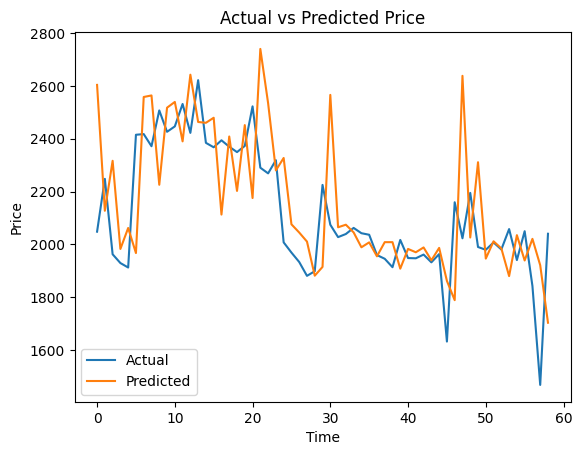

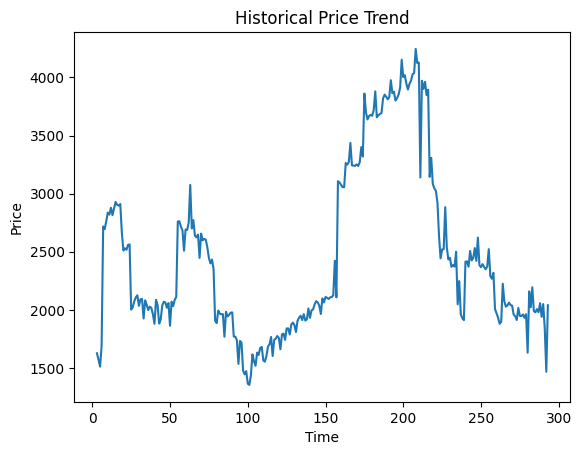

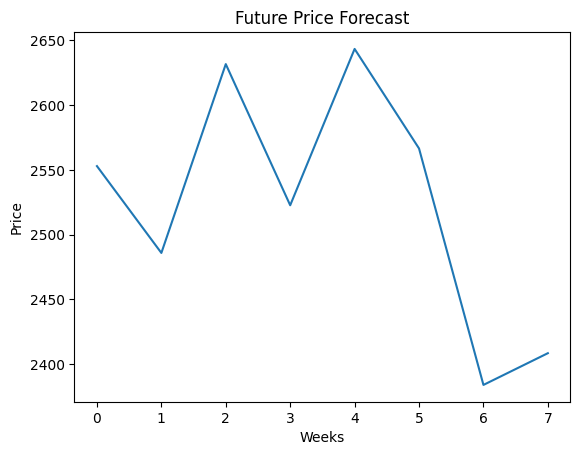

In [5]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# ==========================================
# LOAD DATA
# ==========================================

mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")

print(mandi_df.head())
print(mandi_df.columns)


# ==========================================
# DATA CLEANING
# ==========================================

mandi_df = mandi_df.dropna(subset=["modal_price"])

date_col = "date"
mandi_df[date_col] = pd.to_datetime(mandi_df[date_col])

mandi_df = mandi_df.sort_values(date_col)


# ==========================================
# TIME SERIES PREPARATION
# ==========================================

ts = mandi_df[[date_col,"modal_price"]]

ts = ts.groupby(date_col).mean().reset_index()

ts["Lag1"] = ts["modal_price"].shift(1)
ts["Lag2"] = ts["modal_price"].shift(2)
ts["Lag3"] = ts["modal_price"].shift(3)

ts = ts.dropna()


# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X = ts[["Lag1","Lag2","Lag3"]]
y = ts["modal_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,shuffle=False
)


# ==========================================
# TRAIN MODEL
# ==========================================

model = XGBRegressor()

model.fit(X_train,y_train)

print("Model Trained")


# ==========================================
# PREDICTION
# ==========================================

y_pred = model.predict(X_test)


# ==========================================
# EVALUATION METRICS
# ==========================================

r2 = r2_score(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))

print("\nModel Evaluation")
print("R2 Score:",r2)
print("MAE:",mae)
print("RMSE:",rmse)


# ==========================================
# GRAPH 1: ACTUAL VS PREDICTED
# ==========================================

plt.figure()

plt.plot(y_test.values,label="Actual")
plt.plot(y_pred,label="Predicted")

plt.title("Actual vs Predicted Price")
plt.xlabel("Time")
plt.ylabel("Price")

plt.legend()

plt.show()


# ==========================================
# GRAPH 2: PRICE TREND
# ==========================================

plt.figure()

plt.plot(ts["modal_price"])

plt.title("Historical Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()


# ==========================================
# FUTURE FORECAST
# ==========================================

future_weeks = 8

last_known = ts.copy()

future_predictions = []

for i in range(future_weeks):

    lag1 = last_known["modal_price"].iloc[-1]
    lag2 = last_known["modal_price"].iloc[-2]
    lag3 = last_known["modal_price"].iloc[-3]

    X_future = pd.DataFrame({
        "Lag1":[lag1],
        "Lag2":[lag2],
        "Lag3":[lag3]
    })

    pred = model.predict(X_future)[0]

    future_predictions.append(pred)

    new_row = pd.DataFrame({
        "modal_price":[pred]
    })

    last_known = pd.concat([last_known,new_row],ignore_index=True)


plt.figure()

plt.plot(future_predictions)

plt.title("Future Price Forecast")
plt.xlabel("Weeks")
plt.ylabel("Price")

plt.show()

Columns in dataset:
Index(['state', 'district', 'market', 'crop', 'variety', 'grade', 'min_price',
       'max_price', 'modal_price', 'date'],
      dtype='object')


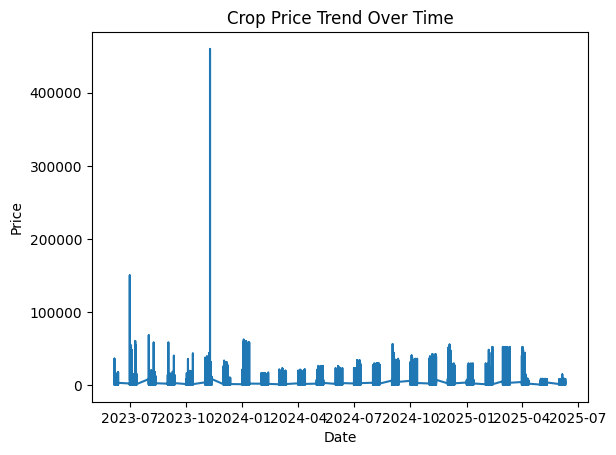

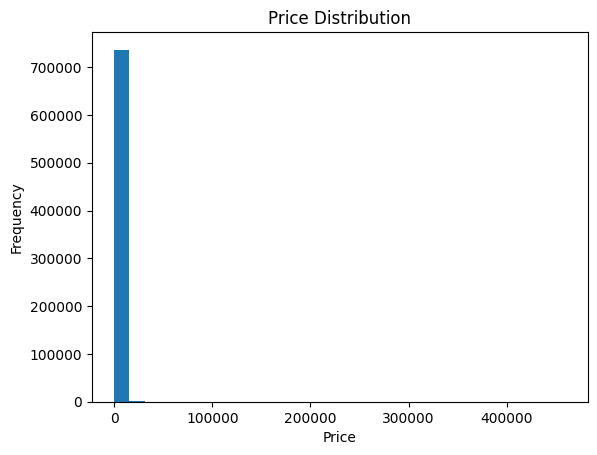

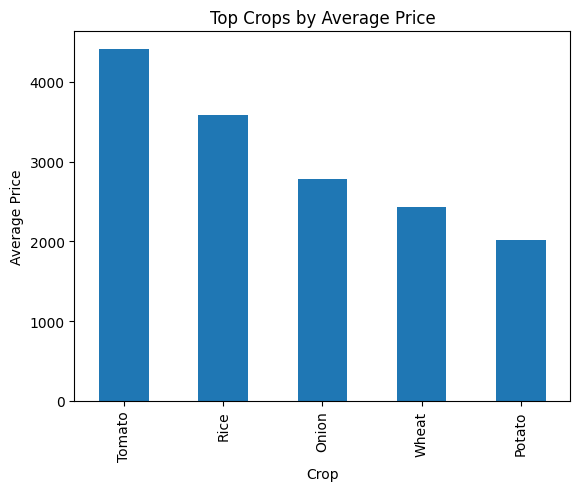

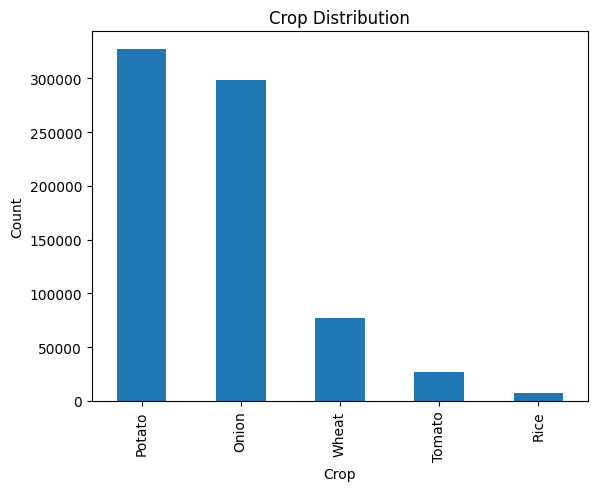

Model Trained


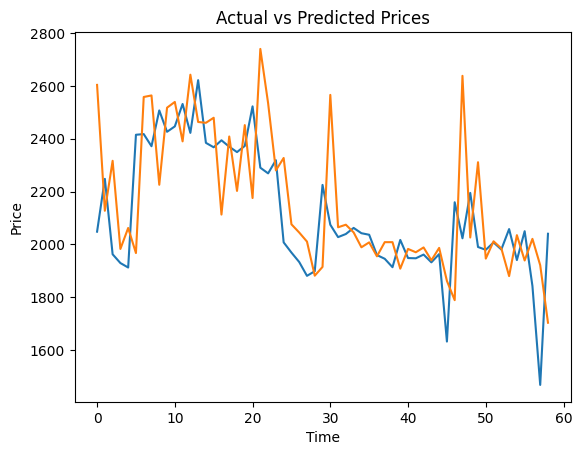


Evaluation Metrics
R2 Score: 0.04678505709861858
MAE: 169.15796049254578
RMSE: 227.9035725731414


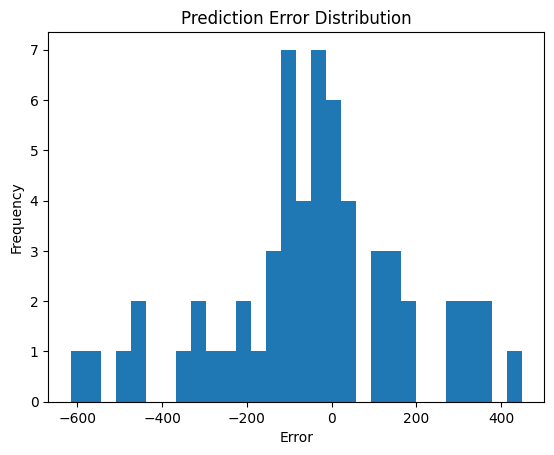

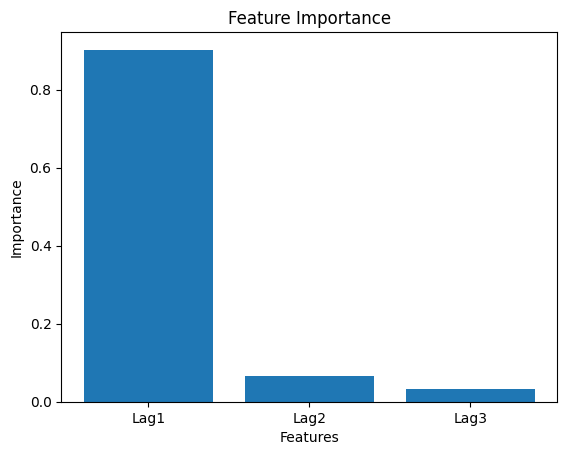

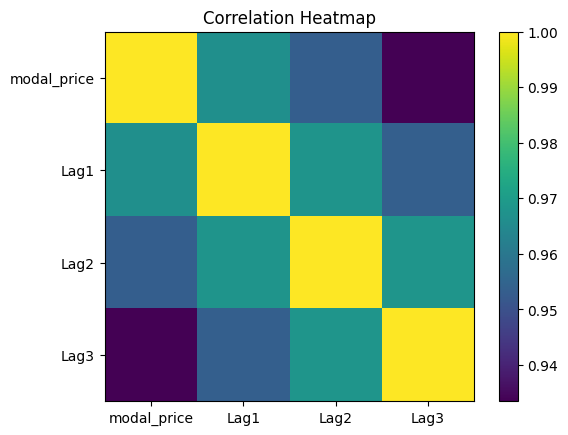

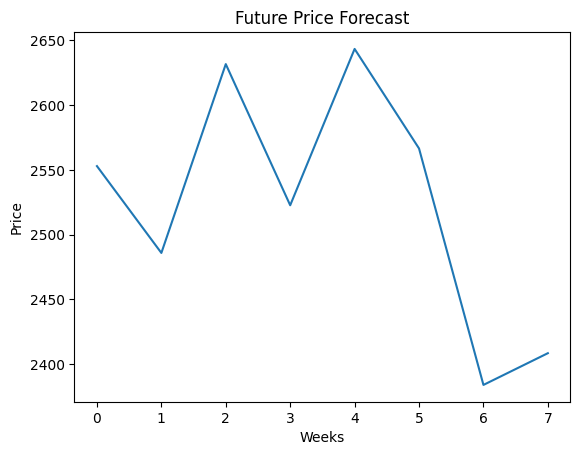

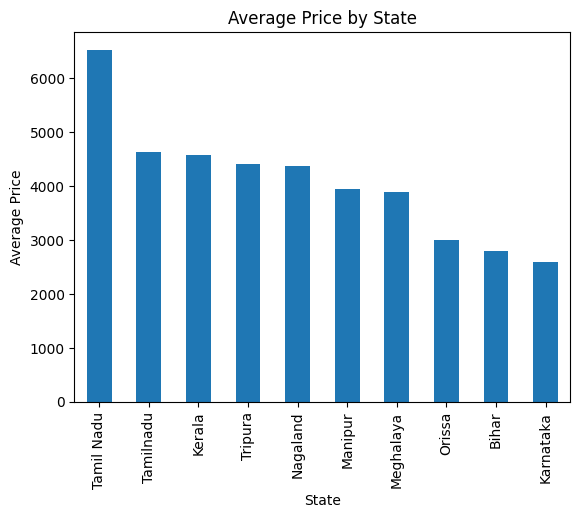

In [6]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor


# =====================================================
# LOAD DATASET
# =====================================================

mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")

print("Columns in dataset:")
print(mandi_df.columns)


# =====================================================
# DATA CLEANING
# =====================================================

mandi_df = mandi_df.dropna(subset=["modal_price"])

mandi_df["date"] = pd.to_datetime(mandi_df["date"])

mandi_df = mandi_df.sort_values("date")


# =====================================================
# GRAPH 1: PRICE TREND
# =====================================================

plt.figure()

plt.plot(mandi_df["date"], mandi_df["modal_price"])

plt.title("Crop Price Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()


# =====================================================
# GRAPH 2: PRICE DISTRIBUTION
# =====================================================

plt.figure()

plt.hist(mandi_df["modal_price"], bins=30)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()


# =====================================================
# GRAPH 3: TOP CROPS BY PRICE
# =====================================================

crop_price = mandi_df.groupby("crop")["modal_price"].mean().sort_values(ascending=False).head(10)

plt.figure()

crop_price.plot(kind="bar")

plt.title("Top Crops by Average Price")
plt.xlabel("Crop")
plt.ylabel("Average Price")

plt.show()


# =====================================================
# GRAPH 4: CROP DISTRIBUTION
# =====================================================

crop_counts = mandi_df["crop"].value_counts().head(10)

plt.figure()

crop_counts.plot(kind="bar")

plt.title("Crop Distribution")
plt.xlabel("Crop")
plt.ylabel("Count")

plt.show()


# =====================================================
# PREPARE TIME SERIES DATA
# =====================================================

ts = mandi_df[["date","modal_price"]]

ts = ts.groupby("date").mean().reset_index()

ts["Lag1"] = ts["modal_price"].shift(1)
ts["Lag2"] = ts["modal_price"].shift(2)
ts["Lag3"] = ts["modal_price"].shift(3)

ts = ts.dropna()


# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X = ts[["Lag1","Lag2","Lag3"]]
y = ts["modal_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# =====================================================
# TRAIN MODEL
# =====================================================

model = XGBRegressor()

model.fit(X_train, y_train)

print("Model Trained")


# =====================================================
# PREDICTION
# =====================================================

y_pred = model.predict(X_test)


# =====================================================
# GRAPH 5: ACTUAL VS PREDICTED
# =====================================================

plt.figure()

plt.plot(y_test.values)
plt.plot(y_pred)

plt.title("Actual vs Predicted Prices")
plt.xlabel("Time")
plt.ylabel("Price")

plt.show()


# =====================================================
# EVALUATION METRICS
# =====================================================

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\nEvaluation Metrics")
print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


# =====================================================
# GRAPH 6: ERROR DISTRIBUTION
# =====================================================

errors = y_test - y_pred

plt.figure()

plt.hist(errors, bins=30)

plt.title("Prediction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")

plt.show()


# =====================================================
# GRAPH 7: FEATURE IMPORTANCE
# =====================================================

importance = model.feature_importances_

features = X.columns

plt.figure()

plt.bar(features, importance)

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()


# =====================================================
# GRAPH 8: CORRELATION HEATMAP
# =====================================================

corr = ts[["modal_price","Lag1","Lag2","Lag3"]].corr()

plt.figure()

plt.imshow(corr)

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.colorbar()

plt.show()


# =====================================================
# GRAPH 9: FUTURE FORECAST
# =====================================================

future_weeks = 8

last_known = ts.copy()

future_predictions = []

for i in range(future_weeks):

    lag1 = last_known["modal_price"].iloc[-1]
    lag2 = last_known["modal_price"].iloc[-2]
    lag3 = last_known["modal_price"].iloc[-3]

    X_future = pd.DataFrame({
        "Lag1":[lag1],
        "Lag2":[lag2],
        "Lag3":[lag3]
    })

    pred = model.predict(X_future)[0]

    future_predictions.append(pred)

    new_row = pd.DataFrame({
        "modal_price":[pred]
    })

    last_known = pd.concat([last_known,new_row], ignore_index=True)


plt.figure()

plt.plot(future_predictions)

plt.title("Future Price Forecast")
plt.xlabel("Weeks")
plt.ylabel("Price")

plt.show()


# =====================================================
# GRAPH 10: PRICE BY STATE
# =====================================================

state_price = mandi_df.groupby("state")["modal_price"].mean().sort_values(ascending=False).head(10)

plt.figure()

state_price.plot(kind="bar")

plt.title("Average Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")

plt.show()


Model: Random Forest
R2: 0.609835393583254
MAE: 109.68510091604631
RMSE: 146.94034458493806

Model: XGBoost
R2: 0.5914577741725519
MAE: 107.67280796466376
RMSE: 150.36113464150057

Model: SVM
R2: -1.0437516123085908
MAE: 279.4348018933034
RMSE: 336.3033359040602

Model Comparison Table
           Model        R2         MAE        RMSE
0  Random Forest  0.609835  109.685101  146.940345
1        XGBoost  0.591458  107.672808  150.361135
2            SVM -1.043752  279.434802  336.303336


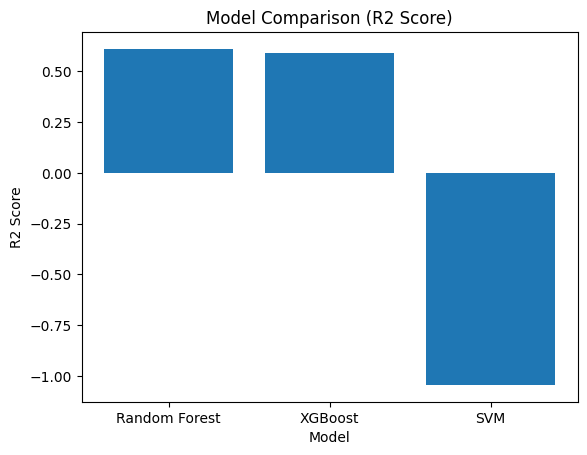

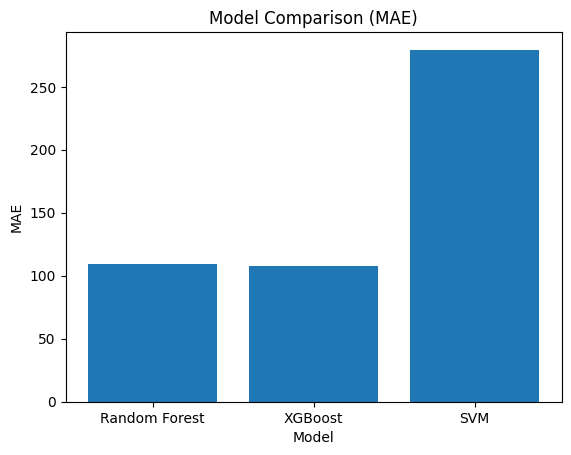

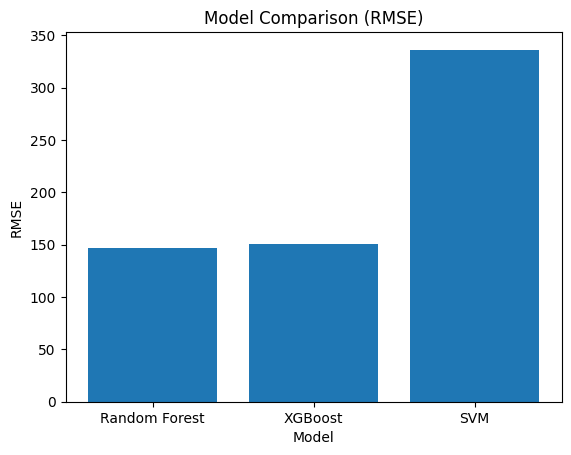

In [1]:
# ======================================================
# IMPORT LIBRARIES
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


# ======================================================
# LOAD DATA
# ======================================================

mandi_df = pd.read_csv("../processed_data/cleaned_mandi_prices.csv")

mandi_df = mandi_df.dropna(subset=["modal_price"])

mandi_df["date"] = pd.to_datetime(mandi_df["date"])

mandi_df = mandi_df.sort_values("date")


# ======================================================
# TIME SERIES DATA
# ======================================================

ts = mandi_df[["date","modal_price"]]

ts = ts.groupby("date").mean().reset_index()

# Lag features
ts["Lag1"] = ts["modal_price"].shift(1)
ts["Lag2"] = ts["modal_price"].shift(2)
ts["Lag3"] = ts["modal_price"].shift(3)

# Rolling features (improves model)
ts["Rolling_mean"] = ts["modal_price"].rolling(7).mean()
ts["Rolling_std"] = ts["modal_price"].rolling(7).std()

ts = ts.dropna()


# ======================================================
# TRAIN TEST SPLIT
# ======================================================

X = ts[["Lag1","Lag2","Lag3","Rolling_mean","Rolling_std"]]
y = ts["modal_price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)


# ======================================================
# MODELS
# ======================================================

models = {

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42
    ),

    "SVM": SVR(
        kernel="rbf"
    )
}


# ======================================================
# TRAIN + EVALUATE MODELS
# ======================================================

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append([name, r2, mae, rmse])

    print("\nModel:", name)
    print("R2:", r2)
    print("MAE:", mae)
    print("RMSE:", rmse)


# ======================================================
# RESULT TABLE
# ======================================================

results_df = pd.DataFrame(
    results,
    columns=["Model","R2","MAE","RMSE"]
)

print("\nModel Comparison Table")
print(results_df)


# ======================================================
# GRAPH: MODEL COMPARISON (R2)
# ======================================================

plt.figure()

plt.bar(results_df["Model"], results_df["R2"])

plt.title("Model Comparison (R2 Score)")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.show()


# ======================================================
# GRAPH: MAE COMPARISON
# ======================================================

plt.figure()

plt.bar(results_df["Model"], results_df["MAE"])

plt.title("Model Comparison (MAE)")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.show()


# ======================================================
# GRAPH: RMSE COMPARISON
# ======================================================

plt.figure()

plt.bar(results_df["Model"], results_df["RMSE"])

plt.title("Model Comparison (RMSE)")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.show()